
# Tool-calling LangGraph: ReAct-Loop
The goal of this experiment is to move the developer-designed routing towards the agent itself. The model can decide at runtime which exposed capability to invoke, while LangGraph provides the execution loop and tool infrastructure. Intentionally, for the first and second part, the weather specialist is implemented as a deterministic tool too, such that the Code is not immediately loaded with the additional agent logic. But we will investigate how the proper two-agent scenario can be implemented in the third part. Note for the test: the date must be adjusted!

## Developing the Structure
The structure is implemented in the following first part. The weather specialist is not able to acquire any meaningful weather data, dealing with an API integration is the purpose of the second part below. But although the weather_specialist is not a node, its tool appearance contains an LLM call too.

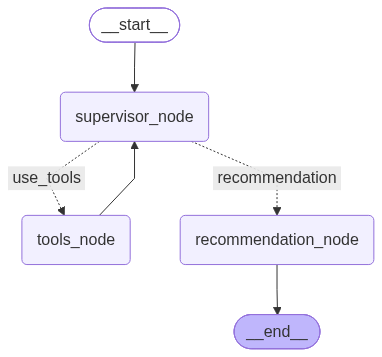


 Supervisor: 

 USING TOOLS: ['weather_specialist', 'load_wardrobe']

 should_continue use tools

 Wardrobe is loaded...

 weather_specialist response: # Berlin Weather Assessment

I don't have access to real-time weather data or live internet feeds, so I can't give you the actual current conditions or today's specific forecast for Berlin.

**To get accurate, current information, I'd recommend:**
- Deutscher Wetterdienst (DWD) - dwd.de (German national weather service)
- weather.com or AccuWeather
- A quick voice search: "Berlin weather today"

**General clothing guidance once you have the numbers:**
- **Temp + wind:** Berlin can feel notably colder with wind chill, especially fall/winter — factor in a windproof layer
- **Precipitation %:** Above 30-40% chance, pack an umbrella/rain shell — Berlin weather shifts quickly
- **Layering:** Berlin's continental climate means decent day/night temperature swings, so layers (base + mid + outer) are usually smarter than one heavy coat
- **Seas

{'messages': [HumanMessage(content='What should I wear today in Berlin?', additional_kwargs={}, response_metadata={}, id='7120dca5-c207-4f9a-b377-baf846572929'),
  AIMessage(content=[{'signature': 'Er4CCqQBCBIYAipAmxGZK5Jgxt0nignrLcmI2sj4GPUi2CI/LZYOjdBk4tD/6U/rduV7MSl4bM9l8Qrfv69RSWdrwlfxVabuQDZ9JzIPY2xhdWRlLXNvbm5ldC01OABCCHRoaW5raW5nWiQzN2Q0NjcwOC00MmQzLTQ1MzgtODMxMS04YjYzZmIxYTgxYTCaAREKD2NsYXVkZS1zb25uZXQtNagBkZSO1gYSDOC53UHAyjDWhJLQyhoM1jfGILNEAKBBsg7TIjC+EVtRTg8b3XqelxRuFFm0+gtSWkLvA03cQ8rw+itzTvSjm2i5dCsD7AtO9+OMo38qR3N7G73TG+JAVSmftMP8Yuv2dvbV+aIIDGiaBBi2e+ktcLos+w+vaxkmdEqpmtIn63ahMAfvea0xnFmACdB4HYxJifBtQgd2GAE=', 'thinking': '', 'type': 'thinking'}, {'id': 'toolu_018YpGrEyzHWCgyxyNmJGeM1', 'caller': {'type': 'direct'}, 'input': {'weather_request': "Current weather and today's forecast for Berlin, Germany"}, 'name': 'weather_specialist', 'type': 'tool_use', 'toolset_name': None}, {'id': 'toolu_01Cr14MjErK2WVopXJtKP1QL', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'loa

In [ ]:
from typing import TypedDict, Annotated, Sequence # Annotated provides context without affecting the type itself; Sequence automatically handles the state updates for sequences such as by adding new messages to the chat history
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage # BM: foundational class for all types in LangGraph (Parent class of AIMessage, HumanMessage, ToolMessage,...); TM: Passes data back to LLM after it calls a tool; SM: Providing instructions to LLM
from langchain_core.tools import tool
from langgraph.graph.message import add_messages # Reducer function: Rule that controls how updates from nodes are combined with the existing state, i.e. tells us how to merge new data into the current state instead of replacing value entirely
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv

load_dotenv(override=True)  # Force loading environment variables from .env file


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


@tool
def load_wardrobe() -> str:
    """Reads and returns the contents of the user's wardrobe."""
    print(f"\n Wardrobe is loaded...")
    with open("wardrobe.md", "r", encoding="utf-8") as f:
        return f.read()

weather_llm = ChatAnthropic(model="claude-sonnet-5")

@tool
def weather_specialist(weather_request: str) -> str:
    """Provides a concise weather assessment for the requested location and time."""

    system_prompt = SystemMessage(
        content=(
            "You are a weather specialist. "
            "Answer the supervisor's weather request with a concise assessment relevant to choosing clothing."
        )
    )

    response = weather_llm.invoke([
        system_prompt,
        HumanMessage(content=weather_request),
    ]) # Is HumanMessage since is input for LLM interaction, although it actually originates from the supervisor LLM
    print(f"\n weather_specialist response: {response.text}")
    return response.text

tools = [load_wardrobe, weather_specialist]


supervisor_llm = ChatAnthropic(model="claude-sonnet-5").bind_tools(tools)

def supervisor(state: AgentState) -> AgentState:

    system_prompt = SystemMessage(
        content="""
        You are the supervisor of a clothing recommendation system.

        You are responsible for producing the final clothing recommendation.

        You have access to two tools:

        - weather_specialist: obtain and interpret weather information
        - load_wardrobe: obtain the user's wardrobe

        Use these tools whenever the information they provide is necessary.

        You may call tools multiple times if necessary.

        Once you have enough information, answer the user directly with the final
        clothing recommendation.

        Do not call a tool when the required information is already available.
        """
    )

    response = supervisor_llm.invoke(
        [system_prompt, *state["messages"]]
    )

    print(f"\n Supervisor: {response.text}")
    if hasattr(response, "tool_calls") and response.tool_calls:
            print(f"\n USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")

    return {"messages": [response]} # compact way of updating the state; reducer function handles appending of message

def recommend_answer(state: AgentState) -> AgentState:

    last_message = state["messages"][-1]

    print("\nFinal recommendation:\n")
    print(last_message.text) # extract content from Anthropics structured messages

    return state

def should_continue(state: AgentState) -> str:
    """Determine if the agent needs further tool call loops or has finished."""
    last_message = state["messages"][-1]

    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        print(f"\n should_continue use tools")
        return "use_tools"

    return "recommendation" # goes to the end edge which leads to the endpoint


graph = StateGraph(AgentState)

graph.add_node("supervisor_node", supervisor)
graph.add_node("tools_node", ToolNode(tools))
graph.add_node("recommendation_node", recommend_answer)

graph.set_entry_point("supervisor_node")    
graph.add_conditional_edges(
    "supervisor_node",
    should_continue,
    {
        "use_tools": "tools_node",
        "recommendation": "recommendation_node",
    },
)
graph.add_edge("tools_node", "supervisor_node")
graph.add_edge("recommendation_node", END)

agent = graph.compile()
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

agent.invoke({"messages": [HumanMessage(content="What should I wear today in Berlin?")]})

## Adding the API - still a one-agent workflow
Inside the weather_specialist tool, the same structure as in the deterministic case is implemented. Only the supervisor follows the ReAct-loop, the weather specialist is a deterministic tool.

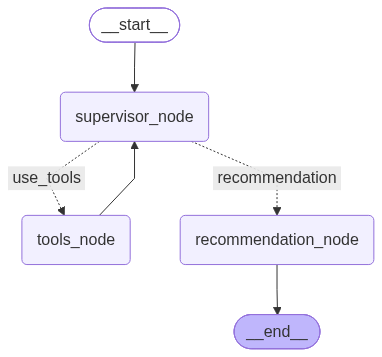


 USING TOOLS: ['weather_specialist', 'load_wardrobe']

 should_continue use tools

 Wardrobe is loaded...

Weather request: city='Berlin, Germany' date='2026-10-05'
Forecast: {'location': 'Berlin, Germany', 'date': '2026-10-05', 'temperatureC': {'min': 8.5, 'max': 21.2}, 'precipitation': {'probabilityPercent': 0, 'totalMm': 0.0}, 'maxWindKmh': 10.8, 'weatherCode': 45} 

Extended forecast:
 ## Weather Assessment: Berlin, Germany — October 5, 2026

**Conditions:** Foggy, with a wide temperature swing from a cool **8.5°C** in the morning to a mild **21.2°C** in the afternoon. No precipitation expected (0% chance), and winds are light (max 10.8 km/h).

**Clothing Recommendations:**
- **Layer up** — start the day with a warm jacket or coat for the brisk, foggy morning (8.5°C feels chilly, especially with reduced visibility).
- **Shed layers by afternoon** — as temperatures climb to 21°C, a light sweater or long-sleeve shirt underneath will let you stay comfortable once it warms up.
- **No 

{'messages': [HumanMessage(content='What should I wear today, october 5 2026, in Berlin?', additional_kwargs={}, response_metadata={}, id='27e921dc-f8ec-461b-a47d-2a775a90fafc'),
  AIMessage(content=[{'signature': 'EqYCCqQBCBIYAipAiOtL3fFv6w+swsVKdQJu/aVKqgWu3Q7fhyhEQVWCL/od1n9O+tfhN7wCsOOHiQrMM24O6Z++UgOmhSwLdSC8qzIPY2xhdWRlLXNvbm5ldC01OABCCHRoaW5raW5nWiQzN2Q0NjcwOC00MmQzLTQ1MzgtODMxMS04YjYzZmIxYTgxYTCaAREKD2NsYXVkZS1zb25uZXQtNagBmPiO1gYSDNQC787TPTQH3vxXMBoMptaUui80B7LJQ5v+IjAnjEpJ1UZKZscGIKBO+IHM8aEiRWxab5FdqHBEBc6jN8qq7j5sQ91b2kWkv85TtUoqL3ykD62zp7nXpljUHHCVp/qULTJq+EBdDckvALtthnSfYBEWOzEN0BXTpuvcnpEsGAE=', 'thinking': '', 'type': 'thinking'}, {'id': 'toolu_01Fva1jRiZLarPePjXzQKMsY', 'caller': {'type': 'direct'}, 'input': {'weather_request': 'Weather forecast for Berlin, Germany on October 5, 2026'}, 'name': 'weather_specialist', 'type': 'tool_use', 'toolset_name': None}, {'id': 'toolu_01K7BW3gB8hscBjfqtuCfX39', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'load_wardrobe', 'ty

In [ ]:
from typing import TypedDict, Annotated, Sequence # Annotated provides context without affecting the type itself; Sequence automatically handles the state updates for sequences such as by adding new messages to the chat history
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage # BM: foundational class for all types in LangGraph (Parent class of AIMessage, HumanMessage, ToolMessage,...); TM: Passes data back to LLM after it calls a tool; SM: Providing instructions to LLM
from langchain_core.tools import tool
from langgraph.graph.message import add_messages # Reducer function: Rule that controls how updates from nodes are combined with the existing state, i.e. tells us how to merge new data into the current state instead of replacing value entirely
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv

load_dotenv(override=True)  # Force loading environment variables from .env file


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


# Same as in deterministic case: the actual http request function calling free Open-Meteo API once for geocoding and then for the weather data
import httpx
def get_forecast(city: str, date: str) -> dict:
    """Get a daily weather forecast from Open-Meteo."""

    geocoding_response = httpx.get(
        "https://geocoding-api.open-meteo.com/v1/search",
        params={
            "name": city,
            "count": 1,
            "language": "en",
            "format": "json",
        },
        timeout=10,
    )
    geocoding_response.raise_for_status()

    places = geocoding_response.json()
    place = places.get("results", [None])[0]

    if not place:
        raise ValueError(f"Could not find a location for {city}.")

    forecast_response = httpx.get(
        "https://api.open-meteo.com/v1/forecast",
        params={
            "latitude": place["latitude"],
            "longitude": place["longitude"],
            "daily": ",".join([
                "weather_code",
                "temperature_2m_max",
                "temperature_2m_min",
                "precipitation_probability_max",
                "precipitation_sum",
                "wind_speed_10m_max",
            ]),
            "timezone": "auto",
            "start_date": date,
            "end_date": date,
        },
        timeout=10,
    )
    forecast_response.raise_for_status()

    daily = forecast_response.json()["daily"]

    return {
        "location": f'{place["name"]}, {place["country"]}',
        "date": date,
        "temperatureC": {
            "min": daily["temperature_2m_min"][0],
            "max": daily["temperature_2m_max"][0],
        },
        "precipitation": {
            "probabilityPercent": daily["precipitation_probability_max"][0],
            "totalMm": daily["precipitation_sum"][0],
        },
        "maxWindKmh": daily["wind_speed_10m_max"][0],
        "weatherCode": daily["weather_code"][0],
    }

## For a structured output of the weather_specialist tool's first LLM call extracting city and date from the request.
from pydantic import BaseModel, Field 
import json 

class WeatherRequest(BaseModel):
    """Parameters required to request weather data."""

    city: str = Field(
        description="The city for which the weather forecast is needed."
    )

    date: str = Field(
        description="The date of the forecast in YYYY-MM-DD format."
    )

# prepare llm: ensure a structured output as above for the first LLM call of the weather_specialist while the second one does not require any formatting, hence the plain base_llm is used there
weather_llm = ChatAnthropic(model="claude-sonnet-5")
weather_request_llm = weather_llm.with_structured_output(
    WeatherRequest,
    method="json_schema",
)

@tool
def weather_specialist(weather_request: str) -> str:
    """Provides a concise weather assessment for the requested location and time."""

    system_prompt = SystemMessage(
        content=(
            "You are a weather specialist agent."
            
            "The supervisor asks you to obtain and interpret weather information."
            
            "First, extract the city and date (in YYYY-MM-DD format) required for the weather request."
            "Then use the provided forecast data to produce a concise weather assessment"
            "relevant to clothing."
            
            "Do not invent weather data."
        )
    )

    # LLM call 1: extract API parameters
    request = weather_request_llm.invoke([
        system_prompt,
        HumanMessage(content=weather_request),
    ])
    print("Weather request:", request)
    
    # API call 
    
    forecast = get_forecast(
        request.city,
        request.date,
    )
    print("Forecast:", forecast, "\n")
    
    # LLM call 2: interpret forecast
    
    response = weather_llm.invoke([
        system_prompt,
        HumanMessage(
            content=(
                f"Original weather request:\n{weather_request}\n\n"
                f"Forecast data:\n{json.dumps(forecast, ensure_ascii=False, indent=2)}"
            )
        ),
    ])
    print("Extended forecast:\n", response.text)

    return response.text




@tool
def load_wardrobe() -> str:
    """Reads and returns the contents of the user's wardrobe."""
    print(f"\n Wardrobe is loaded...\n")
    with open("wardrobe.md", "r", encoding="utf-8") as f:
        return f.read()

tools = [load_wardrobe, weather_specialist]


supervisor_llm = ChatAnthropic(model="claude-sonnet-5").bind_tools(tools)

def supervisor(state: AgentState) -> AgentState:

    system_prompt = SystemMessage(
        content="""
        You are the supervisor of a clothing recommendation system.

        You are responsible for producing the final clothing recommendation.

        You have access to two tools:

        - weather_specialist: obtain and interpret weather information
        - load_wardrobe: obtain the user's wardrobe

        Use these tools whenever the information they provide is necessary.

        You may call tools multiple times if necessary.

        Once you have enough information, answer the user directly with the final
        clothing recommendation.

        Do not call a tool when the required information is already available.
        """
    )

    response = supervisor_llm.invoke(
        [system_prompt, *state["messages"]]
    )

    if hasattr(response, "tool_calls") and response.tool_calls:
        print(f"\n USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")
    else: 
        print("\n Supervisor ready for recommendation.\n")

    return {"messages": [response]} # compact way of updating the state; reducer function handles appending of message

def recommend_answer(state: AgentState) -> AgentState:

    last_message = state["messages"][-1]

    print("\nFinal recommendation:\n")
    print(last_message.text) # extract content from Anthropics structured messages

    return state

def should_continue(state: AgentState) -> str:
    """Determine if the agent needs further tool call loops or has finished."""
    last_message = state["messages"][-1]

    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        print(f"\n should_continue use tools")
        return "use_tools"

    return "recommendation" # goes to the end edge which leads to the endpoint


graph = StateGraph(AgentState)

graph.add_node("supervisor_node", supervisor)
graph.add_node("tools_node", ToolNode(tools))
graph.add_node("recommendation_node", recommend_answer)

graph.set_entry_point("supervisor_node")    
graph.add_conditional_edges(
    "supervisor_node",
    should_continue,
    {
        "use_tools": "tools_node",
        "recommendation": "recommendation_node",
    },
)
graph.add_edge("tools_node", "supervisor_node")
graph.add_edge("recommendation_node", END)

agent = graph.compile()
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

agent.invoke({"messages": [HumanMessage(content="What should I wear today, october 5 2026, in Berlin?")]})

## Nested Graph: a Real Multi-Agent-System
Now, the simple deterministic tool is replaced by a (sub-) agent as entire, standalone StateGraph. It has the capability to call the weather forecast API and hence is a ReAct-loop agent itself. Although the structure becomes nested, the communication remains clear.

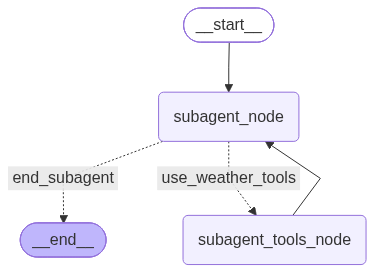

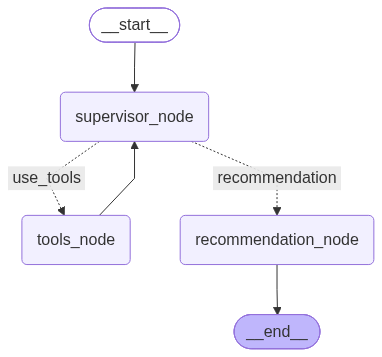


 USING TOOLS: ['ask_weather_specialist', 'load_wardrobe']

 should_continue use tools

 Weather specialist is asked...


 Wardrobe is loaded...


 SUBAGENT response: content=[{'id': 'toolu_01CTUg7CfSSn5c4Exk14gPec', 'caller': {'type': 'direct'}, 'input': {'city': 'Berlin', 'date': '2026-10-05'}, 'name': 'get_forecast', 'type': 'tool_use', 'toolset_name': None}] additional_kwargs={} response_metadata={'id': 'msg_011CfjWad2GCTkzpVSMFY7et', 'container': None, 'model': 'claude-sonnet-5', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 583, 'output_tokens': 78, 'output_tokens_details': {'thinking_tokens': 0}, 'server_tool_use': None, 'service_tier': 'standard'}, 'diagnostics': None, 'model_name': 'claude-sonnet-5', 'model_provider': 'anthropic'} id='lc_run--01a10d2e-3c

{'messages': [HumanMessage(content='What should I wear today, october 5 2026, in Berlin?', additional_kwargs={}, response_metadata={}, id='8a70cbd7-18b8-4019-ac7f-2d751cb62a1e'),
  AIMessage(content=[{'id': 'toolu_01HWApMFeiRhfRiCBL1gEuup', 'caller': {'type': 'direct'}, 'input': {'request': 'What is the weather forecast for Berlin on October 5, 2026? Please include temperature, precipitation, wind, and general conditions.'}, 'name': 'ask_weather_specialist', 'type': 'tool_use', 'toolset_name': None}, {'id': 'toolu_013oaVKofkqLTDUZ1JUuSZC6', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'load_wardrobe', 'type': 'tool_use', 'toolset_name': None}], additional_kwargs={}, response_metadata={'id': 'msg_011CfjWaWCFiMrpWKHdgBAWm', 'container': None, 'model': 'claude-sonnet-5', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_inp

In [ ]:
from typing import TypedDict, Annotated, Sequence # Annotated provides context without affecting the type itself; Sequence automatically handles the state updates for sequences such as by adding new messages to the chat history
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage # BM: foundational class for all types in LangGraph (Parent class of AIMessage, HumanMessage, ToolMessage,...); TM: Passes data back to LLM after it calls a tool; SM: Providing instructions to LLM
from langchain_core.tools import tool
from langgraph.graph.message import add_messages # Reducer function: Rule that controls how updates from nodes are combined with the existing state, i.e. tells us how to merge new data into the current state instead of replacing value entirely
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv

load_dotenv(override=True)  # Force loading environment variables from .env file


# First, the weather_specialist (sub-)agent is implemented as an entire, standalone StateGraph
class WeatherAgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages] # cannot be changed to sub_messages since the ToolNode standard agent mechanism searches for messages


# Same as in deterministic case but now directly a tool for the subagent: the actual http request function calling free Open-Meteo API once for geocoding and then for the weather data
import httpx

@tool
def get_forecast(city: str, date: str) -> dict:
    """Get a daily weather forecast from Open-Meteo."""
    print("Successfully called get_forecast", city, date)
    geocoding_response = httpx.get(
        "https://geocoding-api.open-meteo.com/v1/search",
        params={
            "name": city,
            "count": 1,
            "language": "en",
            "format": "json",
        },
        timeout=10,
    )
    geocoding_response.raise_for_status()

    places = geocoding_response.json()
    place = places.get("results", [None])[0]

    if not place:
        raise ValueError(f"Could not find a location for {city}.")

    forecast_response = httpx.get(
        "https://api.open-meteo.com/v1/forecast",
        params={
            "latitude": place["latitude"],
            "longitude": place["longitude"],
            "daily": ",".join([
                "weather_code",
                "temperature_2m_max",
                "temperature_2m_min",
                "precipitation_probability_max",
                "precipitation_sum",
                "wind_speed_10m_max",
            ]),
            "timezone": "auto",
            "start_date": date,
            "end_date": date,
        },
        timeout=10,
    )
    forecast_response.raise_for_status()

    daily = forecast_response.json()["daily"]

    return {
        "location": f'{place["name"]}, {place["country"]}',
        "date": date,
        "temperatureC": {
            "min": daily["temperature_2m_min"][0],
            "max": daily["temperature_2m_max"][0],
        },
        "precipitation": {
            "probabilityPercent": daily["precipitation_probability_max"][0],
            "totalMm": daily["precipitation_sum"][0],
        },
        "maxWindKmh": daily["wind_speed_10m_max"][0],
        "weatherCode": daily["weather_code"][0],
    }

# Separate ToolNode for the subagent, structure of the agent itself is the same as for the supervisor
weather_tools = [get_forecast]
weather_llm = ChatAnthropic(model="claude-sonnet-5").bind_tools(weather_tools)

def weather_specialist(state: WeatherAgentState) -> dict:

    system_prompt = SystemMessage(
        content="""
        You are a weather specialist.

        Use the get_forecast tool whenever weather data is needed.
        After receiving the forecast, interpret it concisely in terms relevant to clothing.

        Return a concise weather assessment for the supervisor.
        """
    )

    response = weather_llm.invoke(
        [system_prompt, *state["messages"]]
    )
    print("\n SUBAGENT response:", response, "\n")
    if hasattr(response, "tool_calls") and response.tool_calls:
        print(f"\n SUBAGENT USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")
    else: 
        print("\n Subagent ready for returning weather assessment.\n")

    return {"messages": [response]}

def weather_should_continue(state: WeatherAgentState) -> str:

    last_message = state["messages"][-1]

    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        print(f"\n Subagent should_continue use tools \n")
        return "use_weather_tools"

    return "end_subagent"


# construct separate StateGraph for the weather specialist agent
weather_graph = StateGraph(WeatherAgentState)
weather_graph.add_node("subagent_node", weather_specialist)
weather_graph.add_node("subagent_tools_node", ToolNode(weather_tools))

weather_graph.add_edge(START, "subagent_node")
weather_graph.add_conditional_edges(
    "subagent_node",
    weather_should_continue,
    {
        "use_weather_tools": "subagent_tools_node",
        "end_subagent": END,
    },
)
weather_graph.add_edge("subagent_tools_node", "subagent_node")

weather_agent = weather_graph.compile()
from IPython.display import Image, display
display(Image(weather_agent.get_graph().draw_mermaid_png()))







# Now, the usual supervisor agent follows as a separate StateGraph, but the tool ask_weather_specialist invokes the above weather specialist agent StateGraph.
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

# adding the whole StateGraph for the weather specialist agent as a tool, giving the nested structure
@tool
def ask_weather_specialist(request: str) -> str:
    """Ask the weather specialist to obtain and interpret weather information."""
    print(f"\n Weather specialist is asked...\n")
    result = weather_agent.invoke({
        "messages": [
            HumanMessage(content=request)
        ]
    })
    return result["messages"][-1].text

@tool
def load_wardrobe() -> str:
    """Reads and returns the contents of the user's wardrobe."""
    print(f"\n Wardrobe is loaded...\n")
    with open("wardrobe.md", "r", encoding="utf-8") as f:
        return f.read()

supervisor_tools = [load_wardrobe, ask_weather_specialist]
supervisor_llm = ChatAnthropic(model="claude-sonnet-5").bind_tools(supervisor_tools)

def supervisor(state: AgentState) -> AgentState:

    system_prompt = SystemMessage(
        content="""
        You are the supervisor of a clothing recommendation system.

        You are responsible for producing the final clothing recommendation.

        You have access to two tools:

        - ask_weather_specialist: obtain and interpret weather information
        - load_wardrobe: obtain the user's wardrobe

        Use these tools whenever the information they provide is necessary.

        You may call tools multiple times if necessary.

        Once you have enough information, answer the user directly with the final
        clothing recommendation.

        Do not call a tool when the required information is already available.
        """
    )

    response = supervisor_llm.invoke(
        [system_prompt, *state["messages"]]
    )

    if hasattr(response, "tool_calls") and response.tool_calls:
        print(f"\n USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")
    else: 
        print("\n Supervisor ready for recommendation.\n")

    return {"messages": [response]} # compact way of updating the state; reducer function handles appending of message

def recommend_answer(state: AgentState) -> AgentState:

    last_message = state["messages"][-1]

    print("\nFinal recommendation:\n")
    print(last_message.text) # extract content from Anthropics structured messages

    return state

def should_continue(state: AgentState) -> str:
    """Determine if the agent needs further tool call loops or has finished."""
    last_message = state["messages"][-1]

    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        print(f"\n should_continue use tools")
        return "use_tools"

    return "recommendation" # goes to the end edge which leads to the endpoint


graph = StateGraph(AgentState)

graph.add_node("supervisor_node", supervisor)
graph.add_node("tools_node", ToolNode(supervisor_tools))
graph.add_node("recommendation_node", recommend_answer)

graph.set_entry_point("supervisor_node")    
graph.add_conditional_edges(
    "supervisor_node",
    should_continue,
    {
        "use_tools": "tools_node",
        "recommendation": "recommendation_node",
    },
)
graph.add_edge("tools_node", "supervisor_node")
graph.add_edge("recommendation_node", END)

agent = graph.compile()
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))




agent.invoke({"messages": [HumanMessage(content="What should I wear today, october 5 2026, in Berlin?")]})